# Silhouette Analysis — Evaluating Clustering Quality

The silhouette score is the most widely used **internal** clustering evaluation metric — it requires no ground truth labels. It measures how well each point fits its assigned cluster compared to other clusters.

---

## Table of Contents
1. [The Clustering Evaluation Problem](#1-problem)
2. [The Silhouette Coefficient — Math](#2-math)
3. [Geometric Interpretation](#3-geometric)
4. [Using Silhouette to Choose K](#4-choosing-k)
5. [Silhouette Plots (Per-Point Analysis)](#5-silhouette-plot)
6. [Other Internal Metrics](#6-other-metrics)
7. [External Metrics (When Labels Are Available)](#7-external)
8. [Silhouette Score Pitfalls](#8-pitfalls)
9. [Full Pipeline: Evaluate Multiple Algorithms](#9-full-pipeline)
10. [Summary](#10-summary)

---
## 1. The Clustering Evaluation Problem

### Why is Evaluation Hard?

In supervised learning, you have ground-truth labels to check predictions against. In clustering:
- There are no labels
- "Good" clustering is subjective — depends on the use case
- The same data can be clustered in multiple equally valid ways

### Two Scenarios

**1. No ground truth** (the common case): Use **internal metrics** — scores computed only from the data and cluster assignments.

**2. Ground truth available** (e.g., after labeling a sample): Use **external metrics** — compare predicted cluster labels to true labels.

### What Makes a Good Clustering?

The core principle, regardless of metric:
- **High intra-cluster cohesion**: points in the same cluster are close to each other
- **High inter-cluster separation**: clusters are far apart from each other

All internal metrics operationalize this principle differently.

---
## 2. The Silhouette Coefficient — Math

For each data point $i$, the silhouette coefficient $s(i)$ measures how well it fits its cluster.

### Step 1 — Cohesion: $a(i)$

$$a(i) = \frac{1}{|C_i| - 1} \sum_{j \in C_i,\, j \neq i} d(i, j)$$

The **mean distance** from point $i$ to all other points in its own cluster $C_i$.

- Small $a(i)$ → point $i$ is close to its cluster members → good cohesion

### Step 2 — Separation: $b(i)$

For each cluster $C_k \neq C_i$, compute the mean distance from $i$ to all points in $C_k$:

$$d(i, C_k) = \frac{1}{|C_k|} \sum_{j \in C_k} d(i, j)$$

Then take the **minimum** over all other clusters:

$$b(i) = \min_{C_k \neq C_i} d(i, C_k)$$

- $b(i)$ is the distance from $i$ to the **nearest other cluster**
- Large $b(i)$ → point $i$ is well-separated from other clusters → good separation
- The cluster achieving the minimum $b(i)$ is the **neighboring cluster** of point $i$

### Step 3 — Silhouette Score: $s(i)$

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))}$$

**Interpretation**:

| $s(i)$ value | Meaning |
|---|---|
| Close to +1 | Point is well inside its cluster, far from neighboring clusters |
| Close to 0 | Point is near the boundary between two clusters |
| Close to -1 | Point is closer to the neighboring cluster than to its own — likely misassigned |

### Average Silhouette Score

$$\bar{s} = \frac{1}{n} \sum_{i=1}^{n} s(i)$$

Used to compare different values of $K$ or different clustering algorithms. **Higher is better.**

### Computational Cost

Computing all pairwise distances takes $O(n^2)$. For large datasets, use `silhouette_samples` on a random subset or use `sample_size` parameter in `silhouette_score`.

In [1]:
import numpy as np

def silhouette_score_scratch(X, labels):
    """
    Compute silhouette score from scratch using Euclidean distance.
    Returns: mean silhouette, array of per-point silhouette values.
    """
    from scipy.spatial.distance import cdist
    n = len(X)
    unique_labels = np.unique(labels)

    # Precompute all pairwise distances
    D = cdist(X, X, 'euclidean')

    a_vals = np.zeros(n)
    b_vals = np.zeros(n)

    for i in range(n):
        own_cluster = labels[i]
        own_mask = (labels == own_cluster)
        own_mask[i] = False  # exclude self

        if own_mask.sum() == 0:
            a_vals[i] = 0  # singleton cluster
        else:
            a_vals[i] = D[i, own_mask].mean()

        # Mean distance to each other cluster
        mean_dists_to_other = []
        for other_label in unique_labels:
            if other_label == own_cluster:
                continue
            other_mask = (labels == other_label)
            mean_dists_to_other.append(D[i, other_mask].mean())

        b_vals[i] = min(mean_dists_to_other) if mean_dists_to_other else 0

    denom = np.maximum(a_vals, b_vals)
    s_vals = np.where(denom == 0, 0, (b_vals - a_vals) / denom)
    return s_vals.mean(), s_vals


# Verify against sklearn
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X_b, _ = make_blobs(150, centers=3, cluster_std=0.7, random_state=42)
X_b = StandardScaler().fit_transform(X_b)
labels_b = KMeans(3, n_init=10, random_state=42).fit_predict(X_b)

score_scratch, per_point_scratch = silhouette_score_scratch(X_b, labels_b)
score_sk = silhouette_score(X_b, labels_b)

print(f"Scratch score: {score_scratch:.6f}")
print(f"sklearn score: {score_sk:.6f}")
print(f"Match: {abs(score_scratch - score_sk) < 1e-5}")

Scratch score: 0.892575
sklearn score: 0.892575
Match: True


---
## 3. Geometric Interpretation

The formula $s(i) = (b(i) - a(i)) / \max(a(i), b(i))$ can be rewritten to reveal its meaning:

**Case 1: $a(i) < b(i)$ (well-classified point)**

$$s(i) = 1 - \frac{a(i)}{b(i)} \in [0, 1]$$

As $a(i) \to 0$ (tightly grouped), $s(i) \to 1$.

**Case 2: $a(i) > b(i)$ (misclassified point)**

$$s(i) = \frac{b(i)}{a(i)} - 1 \in [-1, 0]$$

As $b(i) \to 0$ (very close to another cluster), $s(i) \to -1$.

**Case 3: $a(i) = b(i)$ (boundary point)**

$$s(i) = 0$$

The normalization by $\max(a, b)$ ensures the score always lies in $[-1, 1]$.

---
## 4. Using Silhouette to Choose K

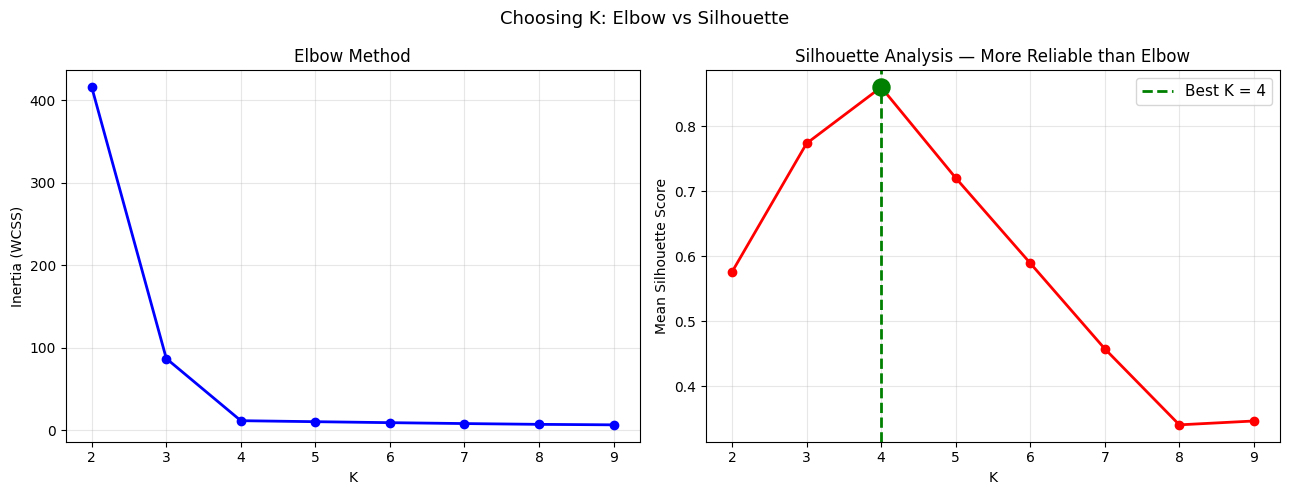

Silhouette scores by K:
  K=2: 0.5762
  K=3: 0.7740
  K=4: 0.8604 ← best
  K=5: 0.7208
  K=6: 0.5896
  K=7: 0.4578
  K=8: 0.3408
  K=9: 0.3468


In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

X_blobs, _ = make_blobs(400, centers=4, cluster_std=0.7, random_state=42)
X_blobs = StandardScaler().fit_transform(X_blobs)

K_range = range(2, 10)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_blobs)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_blobs, labels))

best_k = list(K_range)[np.argmax(sil_scores)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_range, inertias, 'bo-', lw=2)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, sil_scores, 'ro-', lw=2)
axes[1].axvline(best_k, color='green', linestyle='--', lw=2, label=f'Best K = {best_k}')
axes[1].scatter([best_k], [max(sil_scores)], s=150, color='green', zorder=5)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_title('Silhouette Analysis — More Reliable than Elbow')
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

plt.suptitle('Choosing K: Elbow vs Silhouette', fontsize=13)
plt.tight_layout()
plt.savefig('silhouette_choose_k.png', dpi=120, bbox_inches='tight')
plt.show()

print("Silhouette scores by K:")
for k, s in zip(K_range, sil_scores):
    marker = " ← best" if k == best_k else ""
    print(f"  K={k}: {s:.4f}{marker}")

---
## 5. Silhouette Plots (Per-Point Analysis)

The **silhouette plot** visualizes the silhouette score for every individual point, sorted by cluster and by score. This reveals:

- **Cluster width**: the number of points per cluster
- **Cluster quality**: the shape of the silhouette (wide + tall = good)
- **Misclassified points**: negative-score points at the bottom of each cluster
- The **dashed vertical line** shows the mean silhouette — all clusters above this line contribute positively

### Reading the Plot

**Good clustering**: All clusters have similar widths (roughly equal size), all silhouette values are mostly positive, and the average silhouette (vertical line) is high.

**Bad clustering**: Some clusters have very few points (thin), many points have negative scores, or clusters are very unequal in width.

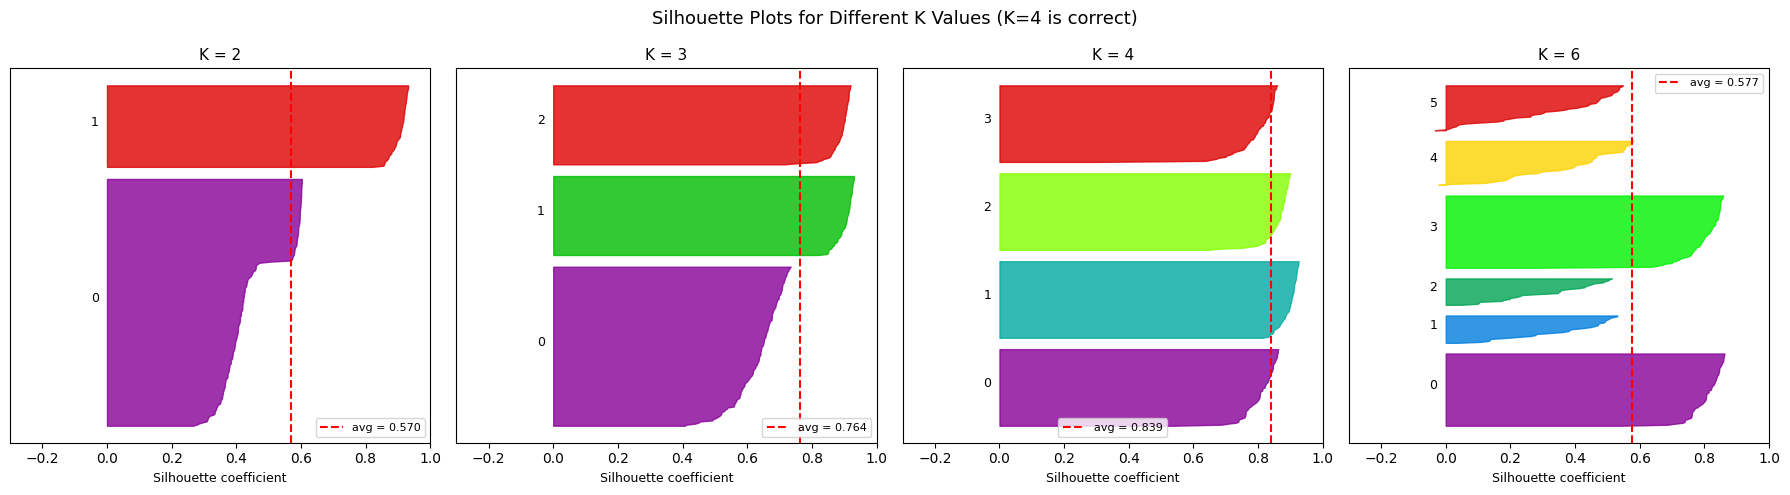

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

X_s, _ = make_blobs(300, centers=4, cluster_std=0.8, random_state=42)
X_s = StandardScaler().fit_transform(X_s)

def plot_silhouette(ax, X, K):
    km = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    sil_vals = silhouette_samples(X, labels)
    avg_sil = sil_vals.mean()

    y_lower = 10
    colors = cm.nipy_spectral(np.linspace(0.1, 0.9, K))

    for k, color in enumerate(colors):
        k_sil = np.sort(sil_vals[labels == k])
        k_size = len(k_sil)
        y_upper = y_lower + k_size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, k_sil,
                         facecolor=color, edgecolor=color, alpha=0.8)
        ax.text(-0.05, y_lower + k_size / 2, str(k), fontsize=9)
        y_lower = y_upper + 10

    ax.axvline(avg_sil, color='red', linestyle='--', lw=1.5,
               label=f'avg = {avg_sil:.3f}')
    ax.set_xlim(-0.3, 1)
    ax.set_xlabel('Silhouette coefficient', fontsize=9)
    ax.set_title(f'K = {K}', fontsize=11)
    ax.set_yticks([])
    ax.legend(fontsize=8)
    return avg_sil

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, k in zip(axes, [2, 3, 4, 6]):
    avg = plot_silhouette(ax, X_s, k)

plt.suptitle('Silhouette Plots for Different K Values (K=4 is correct)', fontsize=13)
plt.tight_layout()
plt.savefig('silhouette_plots.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. Other Internal Metrics

### Davies-Bouldin Index

$$DB = \frac{1}{K} \sum_{i=1}^{K} \max_{j \neq i} \frac{s_i + s_j}{d(\mu_i, \mu_j)}$$

where $s_k$ = average distance from points in cluster $k$ to centroid $\mu_k$ (within-cluster scatter), and $d(\mu_i, \mu_j)$ = distance between centroids.

- Measures ratio of within-cluster spread to between-cluster separation
- **Lower is better** (opposite of silhouette)
- Sensitive to cluster shape and scale

### Calinski-Harabasz Index (Variance Ratio Criterion)

$$CH = \frac{\text{Tr}(B_k) / (K-1)}{\text{Tr}(W_k) / (n-K)}$$

where $B_k$ = between-cluster scatter matrix, $W_k$ = within-cluster scatter matrix.

- Ratio of between-cluster variance to within-cluster variance
- **Higher is better**
- Fast to compute: $O(n \cdot K \cdot d)$
- Assumes convex clusters (favors K-Means-style groupings)

### Inertia (WCSS) — Not Reliable Alone

Inertia always decreases as K increases, so it can't be used directly to compare different K values — only as part of the elbow method (looking at the rate of decrease).

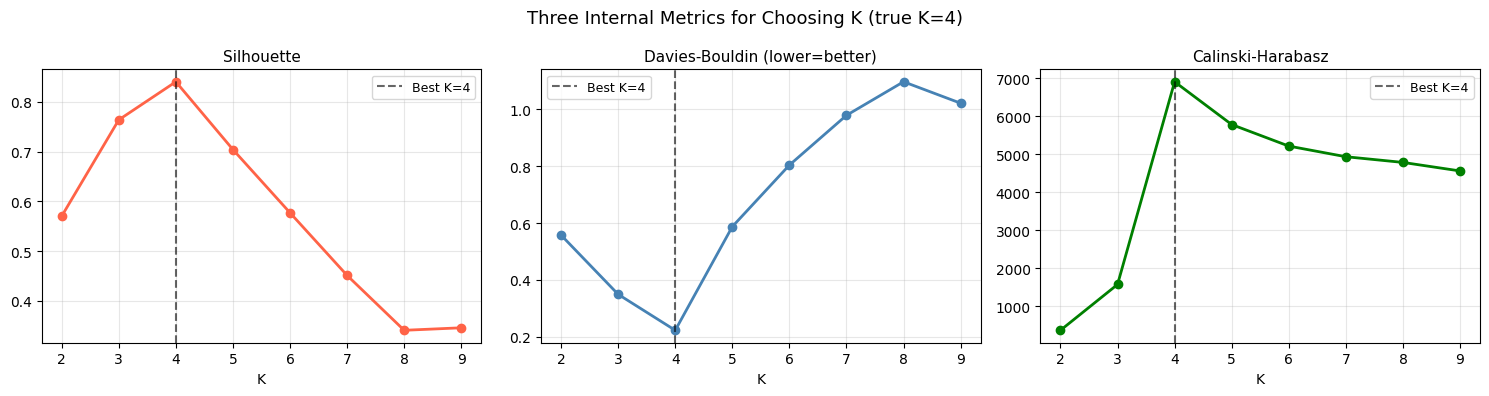

In [4]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

X_m, _ = make_blobs(400, centers=4, cluster_std=0.8, random_state=42)
X_m = StandardScaler().fit_transform(X_m)

K_range = range(2, 10)
results = {'Silhouette': [], 'Davies-Bouldin (lower=better)': [], 'Calinski-Harabasz': []}

for k in K_range:
    km = KMeans(k, init='k-means++', n_init=10, random_state=42)
    lbl = km.fit_predict(X_m)
    results['Silhouette'].append(silhouette_score(X_m, lbl))
    results['Davies-Bouldin (lower=better)'].append(davies_bouldin_score(X_m, lbl))
    results['Calinski-Harabasz'].append(calinski_harabasz_score(X_m, lbl))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metric_colors = ['tomato', 'steelblue', 'green']

for ax, (name, scores), color in zip(axes, results.items(), metric_colors):
    ax.plot(K_range, scores, 'o-', color=color, lw=2)
    # Mark optimal
    if 'lower' in name:
        best = list(K_range)[np.argmin(scores)]
    else:
        best = list(K_range)[np.argmax(scores)]
    ax.axvline(best, color='black', linestyle='--', alpha=0.6, label=f'Best K={best}')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('K')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Three Internal Metrics for Choosing K (true K=4)', fontsize=13)
plt.tight_layout()
plt.savefig('clustering_metrics_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. External Metrics (When Labels Are Available)

When you have true cluster labels (e.g., in a benchmark or after manually labeling), you can measure how well your clustering recovers them.

### Adjusted Rand Index (ARI)

The Rand Index counts the fraction of pairs of points that are **both in the same cluster in both partitions** or **both in different clusters in both partitions**. The Adjusted version corrects for chance:

$$ARI = \frac{RI - E[RI]}{\max(RI) - E[RI]}$$

- Range: $[-1, 1]$ — random clustering → 0, perfect → 1
- **Invariant to label permutation**: cluster 1 in predicted matching cluster 2 in true is fine
- Best general-purpose external metric

### Normalized Mutual Information (NMI)

Measures the mutual information between true and predicted labels, normalized to $[0, 1]$:

$$NMI(U, V) = \frac{2 \cdot I(U; V)}{H(U) + H(V)}$$

where $I$ = mutual information, $H$ = entropy.

- Range $[0, 1]$, higher is better
- Like ARI but from an information-theoretic perspective

### Homogeneity and Completeness

- **Homogeneity** $h$: each cluster contains only members of a single class
- **Completeness** $c$: all members of a class are in the same cluster
- **V-Measure**: harmonic mean $= 2hc/(h+c)$ (like F1 for clustering)

Note: These are **not symmetric** — a clustering can be homogeneous but not complete (assign each class to 10 tiny clusters: each is pure, but the class is split).

In [5]:
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             homogeneity_completeness_v_measure, v_measure_score)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_true = iris.target

algorithms = {
    'K-Means (K=3)': KMeans(3, n_init=20, random_state=42),
    'Ward (K=3)': AgglomerativeClustering(3, linkage='ward'),
    'DBSCAN (ε=0.5)': DBSCAN(eps=0.5, min_samples=5),
}

print(f"{'Algorithm':<20} {'ARI':>8} {'NMI':>8} {'Homog.':>8} {'Compl.':>8} {'V-meas.':>8}")
print('-' * 65)

for name, alg in algorithms.items():
    labels = alg.fit_predict(X_iris)
    # DBSCAN may return -1 labels; ARI/NMI handle this
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    h, c, v = homogeneity_completeness_v_measure(y_true, labels)
    print(f"{name:<20} {ari:>8.4f} {nmi:>8.4f} {h:>8.4f} {c:>8.4f} {v:>8.4f}")

Algorithm                 ARI      NMI   Homog.   Compl.  V-meas.
-----------------------------------------------------------------


K-Means (K=3)          0.6201   0.6595   0.6591   0.6598   0.6595
Ward (K=3)             0.6153   0.6755   0.6579   0.6940   0.6755
DBSCAN (ε=0.5)         0.4421   0.5114   0.5005   0.5228   0.5114


---
## 8. Silhouette Score Pitfalls

### Pitfall 1 — Favors Convex Clusters

Silhouette uses pairwise distances. For non-convex clusters (rings, crescents), the score may be low even if the clustering is correct. DBSCAN on a ring dataset can have lower silhouette than K-Means (which gives a wrong partition) because ring-shaped clusters have high intra-cluster distances.

### Pitfall 2 — Ignores Cluster Density

Two clusters of very different densities can have a low silhouette even if they are well-separated.

### Pitfall 3 — Doesn't Work with 1 Cluster

Silhouette requires at least 2 clusters. `silhouette_score` raises an error for $K = 1$.

### Pitfall 4 — Computational Cost

$O(n^2)$ for computing all pairwise distances. For large datasets ($n > 10{,}000$), compute on a sample:
```python
silhouette_score(X, labels, sample_size=5000)
```

### General Advice

Use **multiple metrics together** and never rely on a single number. The best practice:
1. Plot silhouette + elbow + silhouette per-point
2. Visualize clusters in 2D (PCA)
3. Check if clusters make domain sense

---
## 9. Full Pipeline: Evaluate Multiple Algorithms

Algorithm                K   Silhouette   Davies-Bouldin  Calinski-Harabasz
---------------------------------------------------------------------------
K-Means (K=2)            2       0.3450           1.3123              267.7
K-Means (K=3)            3       0.3144           1.5294              197.1
Ward (K=2)               2       0.3394           1.3700              248.6
Ward (K=3)               3       0.3301           1.5564              182.2
DBSCAN (ε=2)             1          nan              nan                nan


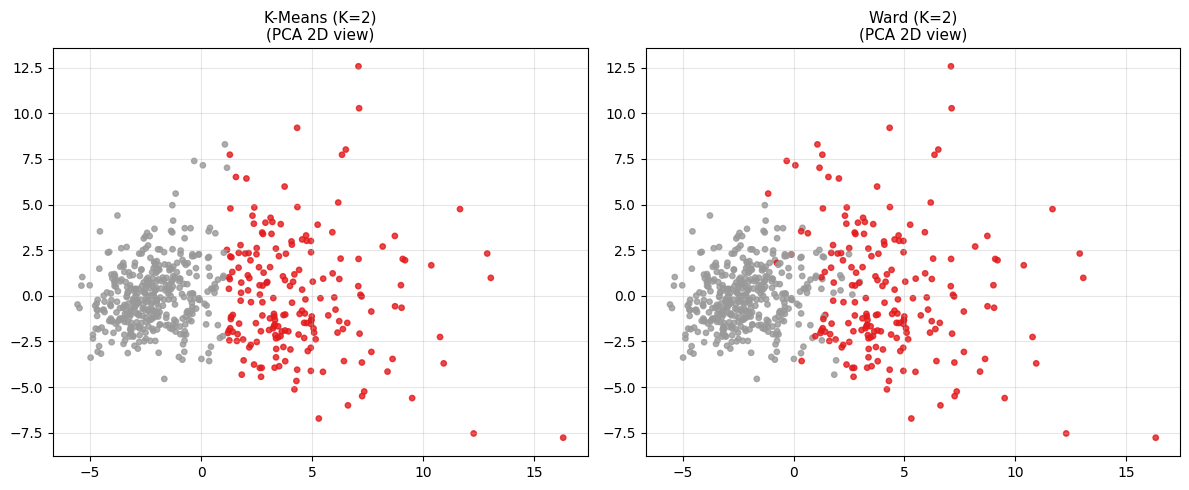

In [6]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import numpy as np

cancer = load_breast_cancer()
X_c = StandardScaler().fit_transform(cancer.data)

algorithms = [
    ('K-Means (K=2)', KMeans(2, n_init=20, random_state=42)),
    ('K-Means (K=3)', KMeans(3, n_init=20, random_state=42)),
    ('Ward (K=2)', AgglomerativeClustering(2, linkage='ward')),
    ('Ward (K=3)', AgglomerativeClustering(3, linkage='ward')),
    ('DBSCAN (ε=2)', DBSCAN(eps=2.0, min_samples=10)),
]

results = []
labels_dict = {}

for name, alg in algorithms:
    lbl = alg.fit_predict(X_c)
    n_c = len(set(lbl)) - (1 if -1 in lbl else 0)
    if n_c < 2:
        results.append((name, n_c, np.nan, np.nan, np.nan))
        continue
    valid = lbl != -1
    sil = silhouette_score(X_c[valid], lbl[valid])
    db = davies_bouldin_score(X_c[valid], lbl[valid])
    ch = calinski_harabasz_score(X_c[valid], lbl[valid])
    results.append((name, n_c, sil, db, ch))
    labels_dict[name] = lbl

print(f"{'Algorithm':<20} {'K':>5} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-Harabasz':>18}")
print('-' * 75)
for name, k, sil, db, ch in results:
    print(f"{name:<20} {k:>5} {sil:>12.4f} {db:>16.4f} {ch:>18.1f}")

# Visualize best algorithms
X_2d = PCA(n_components=2).fit_transform(X_c)
best_algs = [results[0][0], results[2][0]]  # K-Means K=2, Ward K=2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name in zip(axes, best_algs):
    lbl = labels_dict[name]
    noise = lbl == -1
    ax.scatter(X_2d[~noise, 0], X_2d[~noise, 1], c=lbl[~noise], cmap='Set1', s=15, alpha=0.8)
    if noise.any():
        ax.scatter(X_2d[noise, 0], X_2d[noise, 1], c='black', s=15, marker='x')
    ax.set_title(f'{name}\n(PCA 2D view)', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('full_clustering_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 10. Summary

### Silhouette Score Formula

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))} \in [-1, 1]$$

- $a(i)$ = mean intra-cluster distance (cohesion)
- $b(i)$ = mean distance to nearest other cluster (separation)
- Higher is better; +1 = perfect, 0 = boundary, -1 = wrong cluster

### All Clustering Metrics at a Glance

| Metric | Type | Direction | Notes |
|---|---|---|---|
| Silhouette | Internal | Higher better | Best general-purpose internal metric |
| Davies-Bouldin | Internal | Lower better | Ratio of spread to separation |
| Calinski-Harabasz | Internal | Higher better | Fast; favors convex clusters |
| Inertia (WCSS) | Internal | Lower better | Only valid for same K comparison |
| ARI | External | Higher better | Best when labels available |
| NMI | External | Higher better | Information-theoretic |
| V-Measure | External | Higher better | Harmonic mean of homogeneity/completeness |

### Decision Guide

```
Do you have ground-truth labels?
    YES → Use ARI (primary) + NMI (secondary)
    NO  → Use Silhouette (primary) + Davies-Bouldin (secondary)
         + always visualize in 2D with PCA
         + check silhouette plot for per-cluster quality
```

### sklearn Quick Reference
```python
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score)

# Internal (no labels needed)
sil = silhouette_score(X, labels)          # mean silhouette
sil_per_point = silhouette_samples(X, labels)  # one value per point
db  = davies_bouldin_score(X, labels)      # lower = better
ch  = calinski_harabasz_score(X, labels)   # higher = better

# External (need true labels)
ari = adjusted_rand_score(y_true, labels)  # higher = better
nmi = normalized_mutual_info_score(y_true, labels)
```